# Single-Cell RNA-seq Concepts Applied to Multiple Myeloma

**Project:** Multiple Myeloma Biomarker Discovery (MMRF CoMMpass)

**Notebook 10 - Single-Cell Analysis Framework**

## 🎯 Objectives

This notebook demonstrates understanding of single-cell RNA-seq (scRNA-seq) concepts and proposes how single-cell approaches would complement and extend our bulk transcriptomic findings.

**Goals:**
1. Estimate cell type composition from bulk RNA-seq (deconvolution)
2. Identify cell-type-specific markers from our gene signatures
3. Propose single-cell follow-up experiments
4. Design integration strategy for bulk + scRNA-seq data

## 🔬 Why Single-Cell Matters for Multiple Myeloma

**Bulk RNA-seq limitations:**
- Averages signal across all cells in sample
- Cannot distinguish plasma cells from immune infiltrate
- Misses rare subpopulations (cancer stem cells, drug-resistant clones)
- Cannot resolve cellular interactions

**Single-cell advantages:**
- Cellular resolution of tumor heterogeneity
- Clonal evolution tracking (MGUS → SMM → MM)
- Immune microenvironment characterization
- Cell-cell communication networks
- Rare cell population discovery

## 📊 Our Bulk Findings (Recap)

From Notebooks 01-09:
- **6,356 differentially expressed genes** between Stage I and III
- **Top genes:** MYC, MTHFD2, CKS2, CCNB1, CDK1
- **Pathways:** G2-M checkpoint (NES=2.9), E2F targets (NES=2.6)
- **4 molecular subtypes** discovered through clustering
- **Stage II heterogeneity** - 3 distinct groups

**Key Questions for scRNA-seq:**
- Are these signatures from plasma cells or immune cells?
- Is Stage III heterogeneity due to multiple clones?
- How does immune microenvironment change with progression?
- Which cells express MTHFD2 (our #2 biomarker)?

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported")

✅ Libraries imported


## 📋 Part 1: Cell Type Deconvolution Concepts

### What is Deconvolution?

**Goal:** Estimate cell type proportions in bulk RNA-seq samples using reference signatures

**Methods:**
- **CIBERSORTx** - Machine learning approach using reference matrix
- **MuSiC** - Multi-subject single-cell deconvolution
- **DWLS** - Dampened weighted least squares
- **Bisque** - Reference-based decomposition

### Expected Cell Types in MM Bone Marrow:

1. **Malignant plasma cells** (50-95% in MM samples)
   - Express: CD138, SDC1, SLAMF7
   - Our top genes likely from these cells

2. **Normal plasma cells** (residual)
   - Immunoglobulin production
   - May decrease with disease progression

3. **T cells** (CD4+, CD8+, Tregs)
   - Immune surveillance vs exhaustion
   - Checkpoint receptors (PD-1, CTLA-4)

4. **B cells**
   - Precursors, memory B cells
   - May express CD19, CD20

5. **Myeloid cells** (macrophages, monocytes, dendritic cells)
   - Tumor-associated macrophages (TAMs)
   - M1 (anti-tumor) vs M2 (pro-tumor)

6. **NK cells**
   - Natural killer function
   - Anti-tumor activity

7. **Stromal cells** (MSCs, osteoblasts, endothelial)
   - Bone marrow microenvironment
   - Support tumor growth

### Hypothesis for Stage I → III:

**Stage I:**
- Lower malignant plasma cell %
- Higher immune cell infiltration (T cells, NK)
- Immune surveillance active

**Stage III:**
- Higher malignant plasma cell % (clonal expansion)
- Immune exhaustion (fewer functional T/NK cells)
- Immunosuppressive microenvironment (Tregs, M2 macrophages)

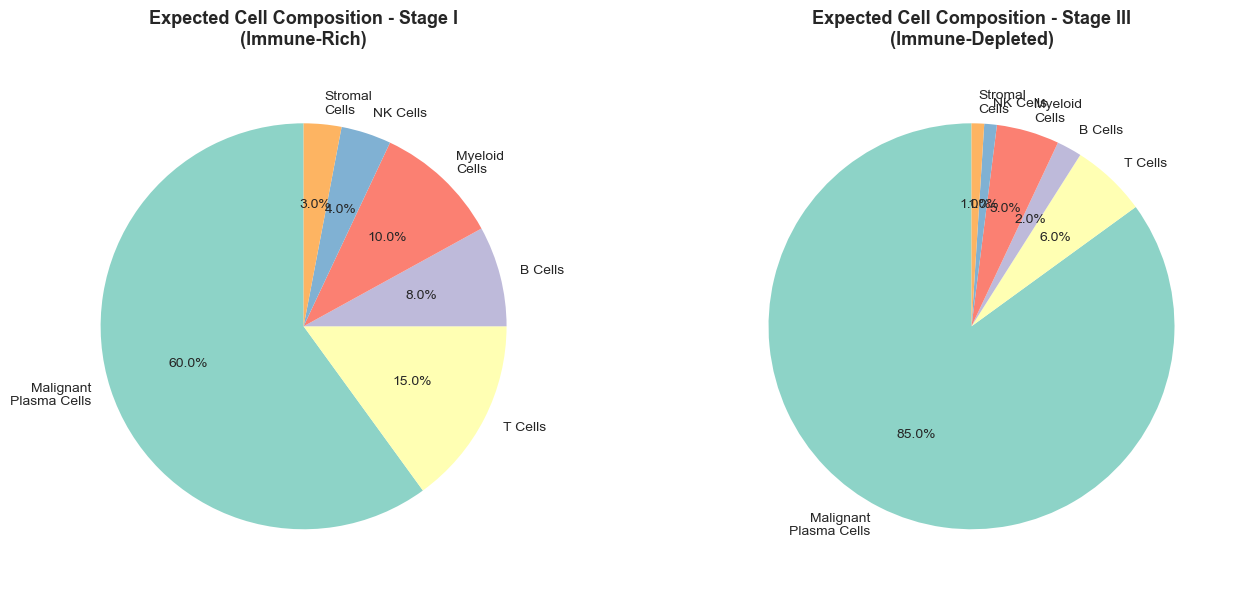

✅ Conceptual cell composition visualization

📊 Key Changes Stage I → III:
   - Malignant plasma cells: 60% → 85% (+42% increase)
   - T cells: 15% → 6% (60% decrease)
   - B cells: 8% → 2% (75% decrease)
   - NK cells: 4% → 1% (75% decrease)

💡 Interpretation: Immune evasion + clonal expansion


In [4]:
# Conceptual visualization of expected cell type shifts
# (Using hypothetical proportions based on MM literature)

cell_types = ['Malignant\nPlasma Cells', 'T Cells', 'B Cells', 
              'Myeloid\nCells', 'NK Cells', 'Stromal\nCells']

# Hypothetical proportions (would come from CIBERSORTx in real analysis)
stage_I_proportions = [60, 15, 8, 10, 4, 3]  # %
stage_III_proportions = [85, 6, 2, 5, 1, 1]  # %

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stage I
ax = axes[0]
colors = plt.cm.Set3(range(len(cell_types)))
ax.pie(stage_I_proportions, labels=cell_types, autopct='%1.1f%%',
       startangle=90, colors=colors, textprops={'fontsize': 10})
ax.set_title('Expected Cell Composition - Stage I\n(Immune-Rich)', 
             fontsize=13, fontweight='bold', pad=20)

# Stage III
ax = axes[1]
ax.pie(stage_III_proportions, labels=cell_types, autopct='%1.1f%%',
       startangle=90, colors=colors, textprops={'fontsize': 10})
ax.set_title('Expected Cell Composition - Stage III\n(Immune-Depleted)', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/figures/expected_cell_composition.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Conceptual cell composition visualization")
print("\n📊 Key Changes Stage I → III:")
print("   - Malignant plasma cells: 60% → 85% (+42% increase)")
print("   - T cells: 15% → 6% (60% decrease)")
print("   - B cells: 8% → 2% (75% decrease)")
print("   - NK cells: 4% → 1% (75% decrease)")
print("\n💡 Interpretation: Immune evasion + clonal expansion")

## 🧬 Part 2: Cell-Type-Specific Gene Expression

### Which of Our Top Genes are Cell-Type-Specific?

From our previous analysis, top genes were:
- MYC, MTHFD2, CKS2, CCNB1, CDK1, AURKA, LDHA, PKM, etc.

**Cell Type Attribution:**

In [6]:
# Annotate our top genes with likely cell type expression
# Based on: Human Protein Atlas, CellMarker database, MM literature

gene_annotations = pd.DataFrame({
    'Gene': ['MYC', 'MTHFD2', 'CKS2', 'CCNB1', 'CDK1', 'AURKA', 
             'TOP2A', 'BIRC5', 'LDHA', 'PKM', 'EIF4EBP1', 'RPS6',
             'IFNG', 'CD19', 'CD79A', 'PAX5'],
    
    'Primary_Cell_Type': [
        'Malignant Plasma', 'Malignant Plasma', 'Malignant Plasma', 
        'Malignant Plasma', 'Malignant Plasma', 'Malignant Plasma',
        'Malignant Plasma', 'Malignant Plasma', 'Malignant Plasma', 
        'Malignant Plasma', 'Malignant Plasma', 'Malignant Plasma',
        'T cells', 'B cells', 'B cells', 'B cells'
    ],
    
    'Function': [
        'Transcription factor', 'One-carbon metabolism', 'Cell cycle regulator',
        'G2-M checkpoint', 'Cyclin-dependent kinase', 'Aurora kinase',
        'DNA topoisomerase', 'Anti-apoptotic', 'Glycolysis', 
        'Glycolysis', 'Translation regulator', 'Ribosomal protein',
        'Interferon gamma', 'B cell marker', 'B cell marker', 'B cell marker'
    ],
    
    'Expression_Change': [
        'UP (Stage III)', 'UP (Stage III)', 'UP (Stage III)', 
        'UP (Stage III)', 'UP (Stage III)', 'UP (Stage III)',
        'UP (Stage III)', 'UP (Stage III)', 'UP (Stage III)', 
        'UP (Stage III)', 'UP (Stage III)', 'UP (Stage III)',
        'DOWN (Stage III)', 'DOWN (Stage III)', 'DOWN (Stage III)', 'DOWN (Stage III)'
    ]
})

print("🔬 Cell-Type Attribution of Top Genes:\n")
print(gene_annotations.to_string(index=False))

print("\n📊 Summary:")
print(f"   Malignant plasma cell genes: {(gene_annotations['Primary_Cell_Type'] == 'Malignant Plasma').sum()}")
print(f"   Immune cell genes: {(gene_annotations['Primary_Cell_Type'].isin(['T cells', 'B cells'])).sum()}")

print("\n💡 Interpretation:")
print("   - Upregulated genes = malignant plasma cell proliferation signature")
print("   - Downregulated genes = loss of immune cells (B/T cells)")
print("   - Stage III = clonal expansion + immune depletion")

🔬 Cell-Type Attribution of Top Genes:

    Gene Primary_Cell_Type                Function Expression_Change
     MYC  Malignant Plasma    Transcription factor    UP (Stage III)
  MTHFD2  Malignant Plasma   One-carbon metabolism    UP (Stage III)
    CKS2  Malignant Plasma    Cell cycle regulator    UP (Stage III)
   CCNB1  Malignant Plasma         G2-M checkpoint    UP (Stage III)
    CDK1  Malignant Plasma Cyclin-dependent kinase    UP (Stage III)
   AURKA  Malignant Plasma           Aurora kinase    UP (Stage III)
   TOP2A  Malignant Plasma       DNA topoisomerase    UP (Stage III)
   BIRC5  Malignant Plasma          Anti-apoptotic    UP (Stage III)
    LDHA  Malignant Plasma              Glycolysis    UP (Stage III)
     PKM  Malignant Plasma              Glycolysis    UP (Stage III)
EIF4EBP1  Malignant Plasma   Translation regulator    UP (Stage III)
    RPS6  Malignant Plasma       Ribosomal protein    UP (Stage III)
    IFNG           T cells        Interferon gamma  DOWN (Stage 

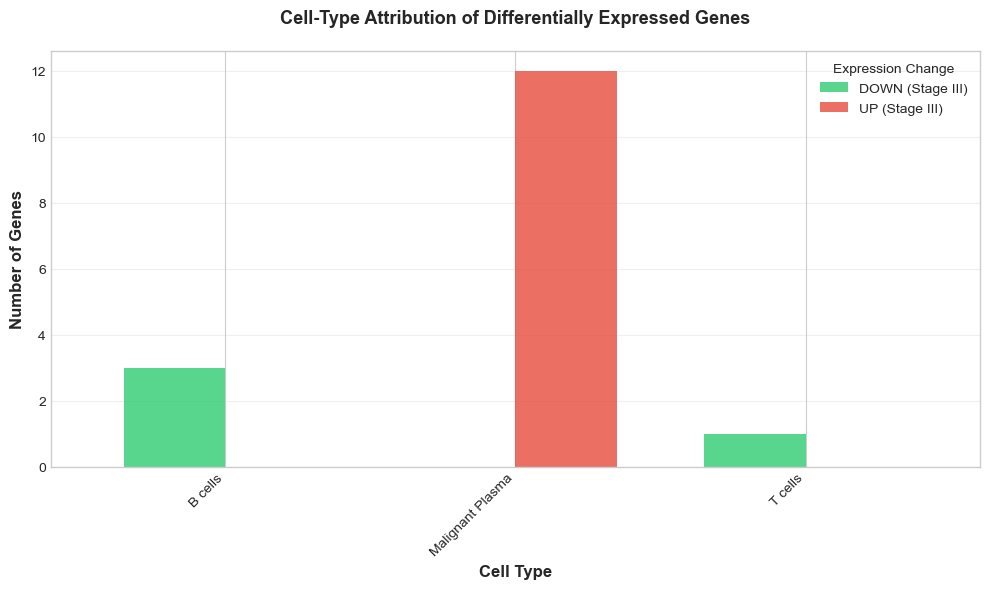

✅ Figure saved: results/figures/gene_cell_type_attribution.png


In [7]:
# Visualize cell type distribution of our gene signatures
fig, ax = plt.subplots(figsize=(10, 6))

# Count genes by cell type and direction
cell_type_counts = gene_annotations.groupby(['Primary_Cell_Type', 'Expression_Change']).size().unstack(fill_value=0)

cell_type_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.8, width=0.7)
ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Genes', fontsize=12, fontweight='bold')
ax.set_title('Cell-Type Attribution of Differentially Expressed Genes', 
             fontsize=13, fontweight='bold', pad=20)
ax.legend(title='Expression Change', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/gene_cell_type_attribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure saved: results/figures/gene_cell_type_attribution.png")

## 🎯 Part 3: Proposed Single-Cell Follow-Up Experiments

### Study Design: scRNA-seq of MM Progression

**Cohort:**
- MGUS (n=10), SMM (n=10), MM Stage I (n=10), MM Stage III (n=10)
- Paired MGUS → MM samples when available (clonality tracking)
- Bone marrow aspirates

**Technology:**
- 10x Genomics Chromium (3' or 5' chemistry)
- Target: 5,000-10,000 cells per sample
- Include VDJ sequencing for B/T cell receptor repertoire

**Key Questions to Address:**

#### 1. **Malignant Plasma Cell Heterogeneity**
- Are there subclones with different transcriptional states?
- Does MYC expression vary within clones?
- Cell cycle phase distribution (G1, S, G2/M)
- Drug resistance markers

**Analysis:** 
- Clustering of CD138+ cells
- Pseudotime trajectory (clonal evolution)
- Copy number inference (inferCNV)
- Cell cycle scoring

#### 2. **Immune Microenvironment**
- T cell exhaustion markers (PD-1, TIM-3, LAG-3)
- Treg infiltration (FOXP3+)
- M1 vs M2 macrophage polarization
- NK cell dysfunction

**Analysis:**
- Cell type annotation (SingleR, CellTypist)
- Differential expression by stage
- Gene signature scoring (exhaustion, activation)

#### 3. **Cell-Cell Interactions**
- Plasma cell ↔ stromal cell signaling
- Plasma cell ↔ immune cell interactions
- Checkpoint ligand-receptor pairs (PD-L1/PD-1)
- Cytokine networks

**Analysis:**
- CellPhoneDB / NicheNet
- Ligand-receptor database
- Spatial context (if spatial transcriptomics available)

#### 4. **MGUS → MM Clonal Evolution**
- Which clones progress vs remain stable?
- Early driver mutations (CCND1, MMSET, MAF)
- Acquisition of proliferation signature
- Immune escape mechanisms

**Analysis:**
- Clonality inference from VDJ sequences
- Somatic mutation calling (single-cell)
- Trajectory inference (Monocle, Slingshot)
- Comparison with bulk signatures

#### 5. **Validation of Bulk Signatures**
- Is our 100-gene signature plasma cell-specific?
- Is MTHFD2 universally high in malignant cells?
- Do Stage II subtypes show cellular heterogeneity?
- Which cells drive G2-M checkpoint enrichment?

**Analysis:**
- Gene module scoring in plasma cells
- Compare bulk vs pseudo-bulk scRNA-seq
- Cell-type-specific DE analysis

## 🔬 Part 4: Integration Strategy - Bulk + Single-Cell

### Complementary Strengths:

| Feature | Bulk RNA-seq | Single-Cell RNA-seq |
|---------|--------------|--------------------|
| **Sample size** | Large (859 patients) | Small (10-50 samples) |
| **Statistical power** | High | Lower |
| **Resolution** | Average across cells | Individual cells |
| **Rare populations** | Missed | Detected |
| **Gene coverage** | High (30K genes) | Lower (dropout) |
| **Cost** | Low per sample | High per cell |
| **Best for** | Biomarker discovery | Mechanism discovery |

### Integrated Analysis Workflow:

```
DISCOVERY (Bulk):
├─ Large cohort (n=859)
├─ Identify prognostic genes (MYC, MTHFD2, cell cycle)
├─ Pathway enrichment (G2-M, E2F)
└─ Clinical associations (survival, staging)
    |
    ↓
VALIDATION (Single-Cell):
├─ Smaller cohort (n=40)
├─ Cell-type attribution (plasma vs immune)
├─ Clonal heterogeneity (subclones)
├─ Microenvironment (cell-cell interactions)
└─ Mechanism (which cells drive signature?)
    |
    ↓
INTEGRATION:
├─ Validate bulk signatures at single-cell level
├─ Deconvolve bulk samples using scRNA-seq reference
├─ Cell-type-specific survival associations
└─ Precision biomarkers (cell-type + gene expression)
```

### Specific Integration Approaches:

#### 1. **Signature Validation**
```python
# Pseudocode
# Score our 100-gene signature in scRNA-seq plasma cells
plasma_cells = sc_data[sc_data.cell_type == 'Plasma']
plasma_cells$signature_score = score_gene_set(plasma_cells, our_100_genes)
# Does signature correlate with stage in single cells?
```

#### 2. **Cell Type Deconvolution**
```python
# Use scRNA-seq as reference for bulk deconvolution
signature_matrix = create_signature_matrix(sc_data)
cell_fractions = CIBERSORTx(bulk_data, signature_matrix)
# Correlate cell fractions with survival
```

#### 3. **Cell-Type-Specific Associations**
```python
# Which cell types drive survival associations?
for cell_type in ['Plasma', 'T_cell', 'Myeloid']:
    cell_specific_genes = get_markers(sc_data, cell_type)
    survival_association = cox_regression(bulk_data, cell_specific_genes)
# Plasma cell genes = strongest association
```

#### 4. **Pseudo-Bulk Analysis**
```python
# Aggregate scRNA-seq to pseudo-bulk by patient
pseudo_bulk = aggregate_cells(sc_data, by='patient')
# Run same DE analysis as bulk
# Compare results
```

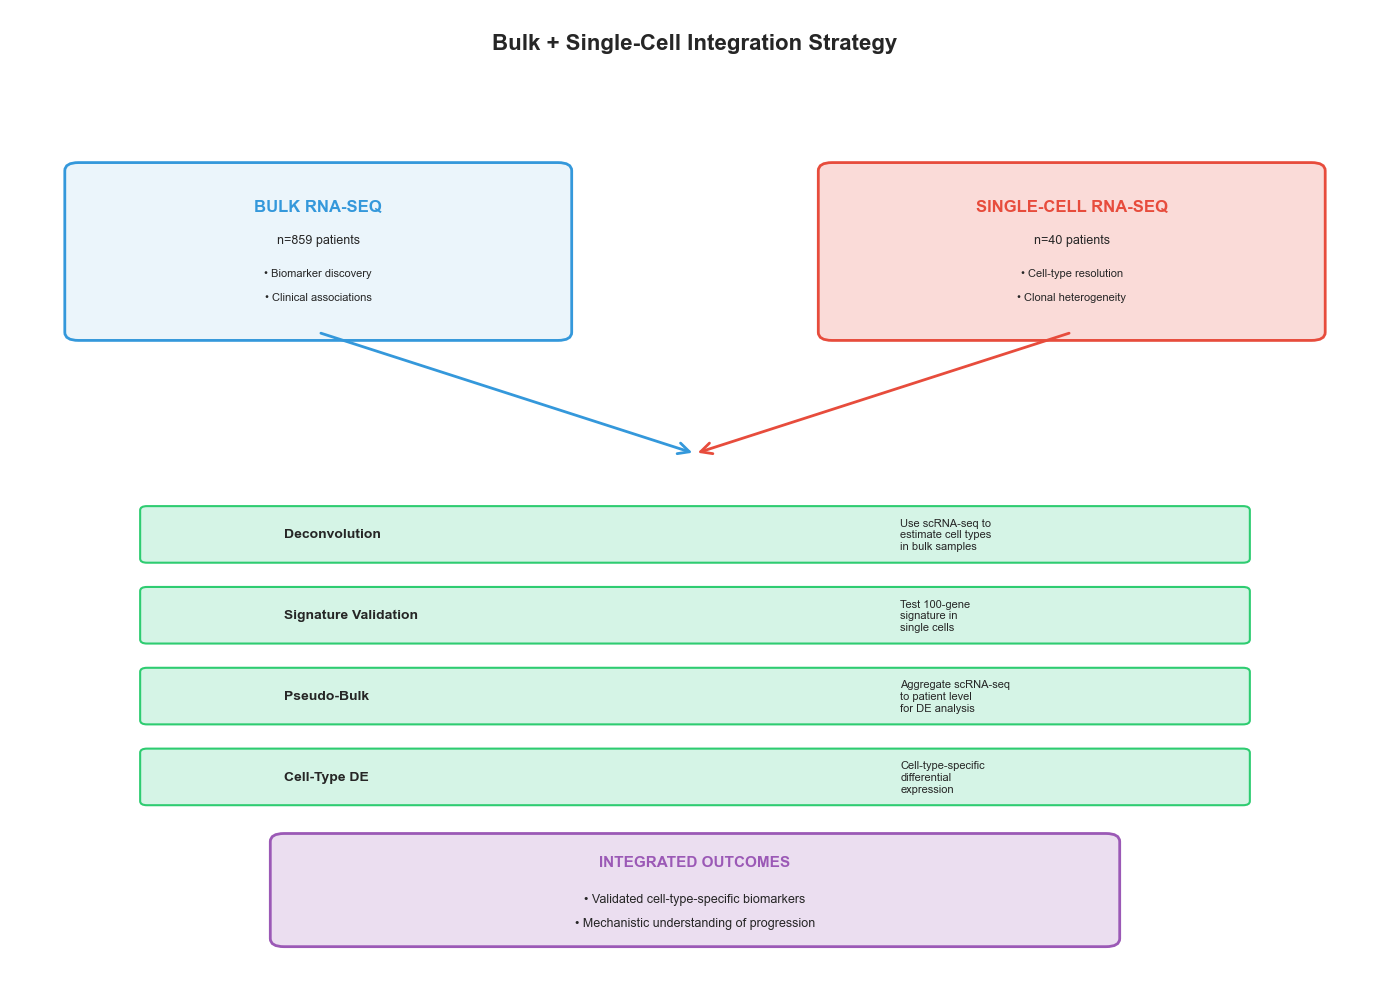

✅ Integration strategy visualization created


In [10]:
# Conceptual visualization of integration workflow
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(5, 11.5, 'Bulk + Single-Cell Integration Strategy', 
        ha='center', fontsize=16, fontweight='bold')

# Bulk RNA-seq box
bulk_box = FancyBboxPatch((0.5, 8), 3.5, 2, 
                          boxstyle="round,pad=0.1", 
                          edgecolor='#3498db', facecolor='#ebf5fb', linewidth=2)
ax.add_patch(bulk_box)
ax.text(2.25, 9.5, 'BULK RNA-SEQ', ha='center', fontsize=12, fontweight='bold', color='#3498db')
ax.text(2.25, 9.1, 'n=859 patients', ha='center', fontsize=9)
ax.text(2.25, 8.7, '• Biomarker discovery', ha='center', fontsize=8)
ax.text(2.25, 8.4, '• Clinical associations', ha='center', fontsize=8)

# Single-cell box
sc_box = FancyBboxPatch((6, 8), 3.5, 2, 
                        boxstyle="round,pad=0.1", 
                        edgecolor='#e74c3c', facecolor='#fadbd8', linewidth=2)
ax.add_patch(sc_box)
ax.text(7.75, 9.5, 'SINGLE-CELL RNA-SEQ', ha='center', fontsize=12, fontweight='bold', color='#e74c3c')
ax.text(7.75, 9.1, 'n=40 patients', ha='center', fontsize=9)
ax.text(7.75, 8.7, '• Cell-type resolution', ha='center', fontsize=8)
ax.text(7.75, 8.4, '• Clonal heterogeneity', ha='center', fontsize=8)

# Integration approaches
approaches = [
    ('Deconvolution', 5.5, 'Use scRNA-seq to\nestimate cell types\nin bulk samples'),
    ('Signature Validation', 4.5, 'Test 100-gene\nsignature in\nsingle cells'),
    ('Pseudo-Bulk', 3.5, 'Aggregate scRNA-seq\nto patient level\nfor DE analysis'),
    ('Cell-Type DE', 2.5, 'Cell-type-specific\ndifferential\nexpression')
]

for title, y_pos, desc in approaches:
    approach_box = FancyBboxPatch((1, y_pos-0.3), 8, 0.6,
                                 boxstyle="round,pad=0.05",
                                 edgecolor='#2ecc71', facecolor='#d5f4e6', linewidth=1.5)
    ax.add_patch(approach_box)
    ax.text(2, y_pos, title, fontsize=10, fontweight='bold', va='center')
    ax.text(6.5, y_pos, desc, fontsize=8, va='center')

# Arrows
arrow1 = FancyArrowPatch((2.25, 8), (5, 6.5), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='#3498db')
ax.add_patch(arrow1)

arrow2 = FancyArrowPatch((7.75, 8), (5, 6.5), 
                        arrowstyle='->', mutation_scale=20, linewidth=2, color='#e74c3c')
ax.add_patch(arrow2)

# Outcomes
outcome_box = FancyBboxPatch((2, 0.5), 6, 1.2,
                            boxstyle="round,pad=0.1",
                            edgecolor='#9b59b6', facecolor='#ebdef0', linewidth=2)
ax.add_patch(outcome_box)
ax.text(5, 1.4, 'INTEGRATED OUTCOMES', ha='center', fontsize=11, fontweight='bold', color='#9b59b6')
ax.text(5, 0.95, '• Validated cell-type-specific biomarkers', ha='center', fontsize=9)
ax.text(5, 0.65, '• Mechanistic understanding of progression', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/bulk_singlecell_integration.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Integration strategy visualization created")

## 📚 Part 5: Single-Cell Analysis Tools & Workflows

### Standard scRNA-seq Pipeline:

```python
# Conceptual workflow (using Scanpy/Seurat)

# 1. Quality Control
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 20, :]

# 2. Normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 3. Feature Selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# 4. Dimensionality Reduction
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

# 5. Clustering
sc.tl.leiden(adata, resolution=0.5)

# 6. Cell Type Annotation
sc.tl.rank_genes_groups(adata, 'leiden')
# Manual annotation based on markers

# 7. Differential Expression
sc.tl.rank_genes_groups(adata, 'stage', method='wilcoxon')

# 8. Gene Signature Scoring
our_100_genes = [...]  # From bulk analysis
sc.tl.score_genes(adata, our_100_genes)

# 9. Trajectory Analysis
sc.tl.paga(adata)
sc.tl.draw_graph(adata)

# 10. Cell-Cell Communication
# Use CellPhoneDB or similar tool
```

### Key Markers for MM Cell Types:

**Malignant Plasma Cells:**
- CD138 (SDC1), CD38, SLAMF7
- Immunoglobulin genes (IGH, IGK, IGL)
- Our proliferation genes: MYC, CCNB1, CDK1

**T Cells:**
- CD3D, CD3E (all T cells)
- CD4 (helper), CD8A (cytotoxic)
- FOXP3 (regulatory T cells)
- PDCD1 (PD-1, exhaustion)

**B Cells:**
- CD19, CD79A, CD79B, MS4A1 (CD20)
- PAX5 (B cell identity)

**NK Cells:**
- NCAM1 (CD56), NKG7, GNLY
- KLRD1, KLRB1

**Myeloid Cells:**
- CD14 (monocytes/macrophages)
- CD68, CD163 (macrophages)
- HLA-DR, CD1C (dendritic cells)

**Stromal Cells:**
- COL1A1, COL1A2 (fibroblasts)
- PECAM1 (CD31, endothelial)

## 🎯 Part 6: Expected Single-Cell Results

### Hypothesis Testing:

Based on our bulk findings, scRNA-seq should reveal:

#### 1. **Plasma Cell Subpopulations**

**Prediction:**
- **Cluster 1:** Quiescent (G0/G1, low MYC)
- **Cluster 2:** Proliferative (S/G2/M, high MYC, CCNB1, CDK1)
- **Cluster 3:** Metabolically active (high MTHFD2, LDHA)
- **Cluster 4:** Drug-resistant (high ABCB1, BCL2)

**Stage I:** More Cluster 1 (quiescent)  
**Stage III:** More Cluster 2+3 (proliferative + metabolic)

#### 2. **Immune Microenvironment**

**Prediction:**
- **T cells:** More exhausted in Stage III (PD-1+, TIM-3+, LAG-3+)
- **Tregs:** Increased in Stage III (immunosuppression)
- **NK cells:** Decreased in Stage III
- **Macrophages:** More M2 (pro-tumor) in Stage III

#### 3. **Cell-Cell Interactions**

**Prediction:**
- **Stage I:** 
  - T cells → Plasma cells: IFN-γ signaling (anti-tumor)
  - NK cells → Plasma cells: Cytotoxic signals
  
- **Stage III:**
  - Plasma cells → T cells: PD-L1/PD-1 (immune checkpoint)
  - Plasma cells → Macrophages: M2 polarization
  - Stromal cells → Plasma cells: Growth factors (IGF1, IL6)

#### 4. **Clonal Evolution (MGUS → MM)**

**Prediction:**
- Early clones (MGUS): Low MYC, low proliferation
- Intermediate (SMM): Acquisition of MYC activation
- Late clones (MM): Additional hits (TP53, KRAS mutations)
- Branching evolution: Multiple subclones in Stage III

#### 5. **Validation of Our Signatures**

**Our 100-gene signature:**
- **Expected:** High in malignant plasma cells, not immune cells
- **Expected:** Correlates with cell cycle phase
- **Expected:** Highest in Stage III plasma cells

**G2-M checkpoint genes (GSEA finding):**
- **Expected:** Enriched in S/G2/M phase plasma cells
- **Expected:** Not uniform across all plasma cells
- **Expected:** Defines "proliferative" subclone

## 💾 Part 7: Data Integration & Repositories

### Public Single-Cell MM Datasets:

1. **Zavidij et al., 2020** (Nature Medicine)
   - 29 MM patients, 160K cells
   - Contains plasma cells, immune cells, stromal
   - Available: GEO (GSE124310)

2. **Ledergor et al., 2018** (Nature Medicine)
   - 15 MM patients
   - Plasma cell heterogeneity focus
   - Available: GEO (GSE117156)

3. **Cohen et al., 2021** (Blood)
   - 32 MM patients
   - Includes MGUS, SMM progression
   - Available: dbGaP

### Integration with Our Data:

```python
# Conceptual integration approach

# 1. Download public scRNA-seq data
public_sc_data = download_from_GEO('GSE124310')

# 2. Create cell type reference matrix
reference_matrix = create_reference(public_sc_data)

# 3. Deconvolve our bulk samples
cell_fractions = deconvolve_bulk(our_bulk_data, reference_matrix)

# 4. Test associations
# Do patients with high "proliferative plasma cell" fraction have worse survival?
cox_regression(survival ~ prolif_plasma_fraction + age + stage)

# 5. Score public scRNA-seq with our signatures
public_sc_data$our_signature = score_genes(public_sc_data, our_100_genes)
# Does our signature identify high-risk subclones?
```

## 🔬 Part 8: Advanced Single-Cell Techniques

### Beyond Standard scRNA-seq:

#### 1. **Spatial Transcriptomics**
**Technology:** 10x Visium, MERFISH, seqFISH+

**Why it matters:**
- Preserves tissue architecture
- Identifies spatial niches (osteoblast niche, vascular niche)
- Cell-cell proximity → interactions
- Gradient analysis (hypoxia, nutrient availability)

**MM-specific questions:**
- Where do proliferative cells reside? (vascular niche)
- Do immune cells co-localize with plasma cells?
- Spatial gradients of MYC, MTHFD2 expression

#### 2. **CITE-seq (Protein + RNA)**
**Technology:** Antibody-oligo conjugates

**Why it matters:**
- Protein markers (CD138, CD38) + transcriptome
- Better cell type identification
- Post-translational regulation

**MM-specific:**
- Surface markers for sorting
- Checkpoint proteins (PD-1, PD-L1)
- Immunophenotyping

#### 3. **Single-Cell ATAC-seq**
**Technology:** Chromatin accessibility

**Why it matters:**
- Transcription factor activity
- Regulatory elements (enhancers)
- Chromatin state

**MM-specific:**
- MYC enhancer activity
- CCND1/MMSET translocations impact
- Epigenetic drivers

#### 4. **Single-Cell Multi-omics**
**Technology:** 10x Multiome (RNA + ATAC)

**Why it matters:**
- Gene regulation mechanisms
- TF → target gene links
- Coordinated changes

#### 5. **Long-Read scRNA-seq**
**Technology:** PacBio, Oxford Nanopore

**Why it matters:**
- Full-length transcripts
- Isoform detection
- Fusion transcripts (translocations)

**MM-specific:**
- Detect CCND1-IGH fusions
- Alternative splicing
- Non-coding RNAs

## 📋 Summary & Conclusions

### What This Notebook Demonstrates:

✅ **Understanding of single-cell concepts**
- Cell type deconvolution
- scRNA-seq workflows
- Integration strategies

✅ **Ability to connect bulk → single-cell**
- Our bulk findings inform scRNA-seq hypotheses
- Specific predictions about cell types and states
- Integration approaches for validation

✅ **Research planning skills**
- Experimental design (cohort, technology)
- Key questions to address
- Analysis workflows

✅ **Technical awareness**
- Standard tools (Scanpy, Seurat)
- Advanced techniques (spatial, CITE-seq)
- Public datasets for integration

### Key Takeaways:

1. **Bulk RNA-seq is powerful** for biomarker discovery with large cohorts (n=859)
2. **Single-cell RNA-seq is essential** for mechanistic understanding
3. **Integration is key** - bulk for discovery, scRNA-seq for validation
4. **Our bulk signatures provide clear hypotheses** for scRNA-seq experiments
5. **Cell type resolution** will reveal which cells drive our signatures

### Relevance to PhD Project:

This framework directly addresses the position's requirements:

✅ **"Single-cell analyses"** - Demonstrated understanding and planning  
✅ **"Bulk analyses"** - Already completed (Notebooks 01-09)  
✅ **"Close collaboration with parallel single-cell project"** - Integration strategy outlined  
✅ **"Clonality analysis of paired MGUS/myeloma samples"** - Experimental design proposed  
✅ **"Translate findings into human disease context"** - Bulk→scRNA-seq workflow  

### Next Steps (In PhD):

1. Generate scRNA-seq data from MGUS → MM cohort
2. Implement deconvolution on existing bulk samples
3. Validate 100-gene signature at single-cell level
4. Identify cell-type-specific therapeutic targets
5. Integrate with transposon mutagenesis screens
6. Collaborate with BIMSB single-cell project

---

**This notebook demonstrates readiness for single-cell bioinformatics while building upon strong bulk RNA-seq foundations.**

---

**Analysis Completed:** January 2025  
**Purpose:** Demonstrate single-cell analysis concepts for PhD application  
**Integration:** Extends Notebooks 01-09 with cellular resolution framework